In [1]:
from tsgen import SyntheticSeries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose, STL , MSTL
from fft import fft_spectrum, plot_fft
import plotly.graph_objects as go
from plotly.subplots import make_subplots

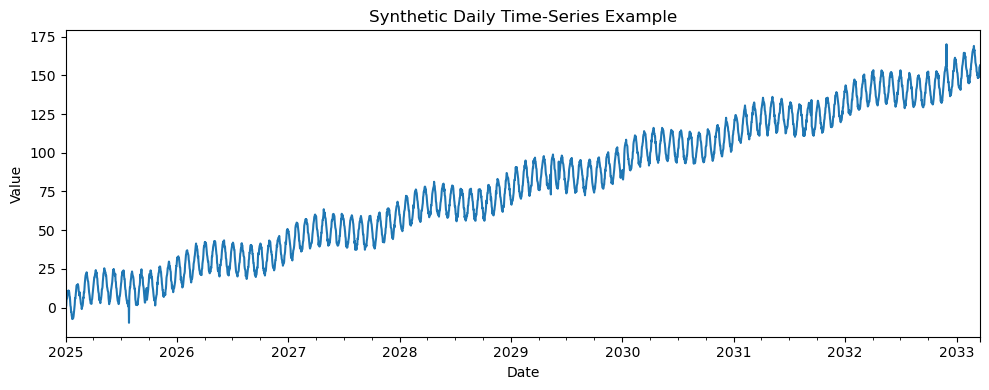

In [11]:
# ------------------------------------------------------------------
# Generate an example synthetic series
# ------------------------------------------------------------------
series = (
    SyntheticSeries("2025-01-01", periods=3000, freq="D", seed=42)
    .add_trend(slope=0.05)                 # gentle upward trend
    .add_seasonality(period=365, amplitude=5)  # monthly-ish cycle
    .add_seasonality(period=30, amplitude=10)   # weekly cycle
    .add_white_noise(std=1.0)              # Gaussian white noise
    .add_spikes(n_spikes=5, magnitude=15)  # occasional outliers
    .add_block_spikes(width=5, n_blocks=2, magnitude=8)
    .add_step_offset("2025-02-15", offset=4)   # permanent upward shift
    .to_series(name="synthetic")
)


# Plot the full series
fig, ax = plt.subplots(figsize=(10, 4))
series.plot(ax=ax)
ax.set_title("Synthetic Daily Time-Series Example")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

   amplitude     frequency                      period
0   9.999119  3.858025e-07            30 days 00:00:00
1   4.416289  3.086420e-08           375 days 00:00:00
2   0.306512  5.401235e-08 214 days 06:51:25.714285713
3   0.291500  6.944444e-08 166 days 15:59:59.999999998


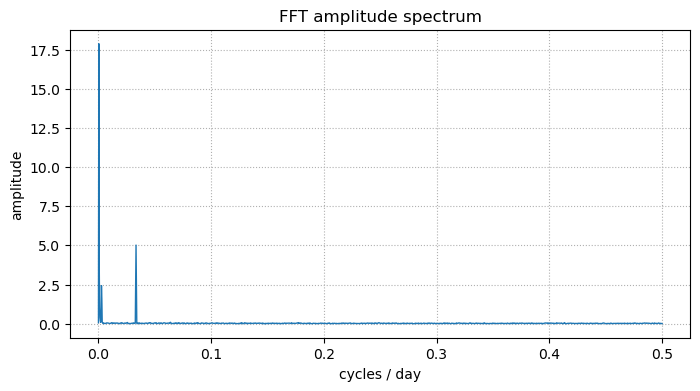

In [12]:


# ts is a Series with a DateTimeIndex
seasonal_peaks = fft_spectrum(series, 
                              detrend="linear", 
                              top_n=4, 
                              min_period = pd.Timedelta(days=400))

print(seasonal_peaks)

plot_fft(series, window="hanning", x_unit="per_day")
plt.show()


c:\Users\paulinkenbrandt\.conda\envs\py313\Lib\site-packages\statsmodels\tsa\stl\mstl.py:218: UserWarning: A period(s) is larger than half the length of time series. Removing these period(s).
  warnings.warn(


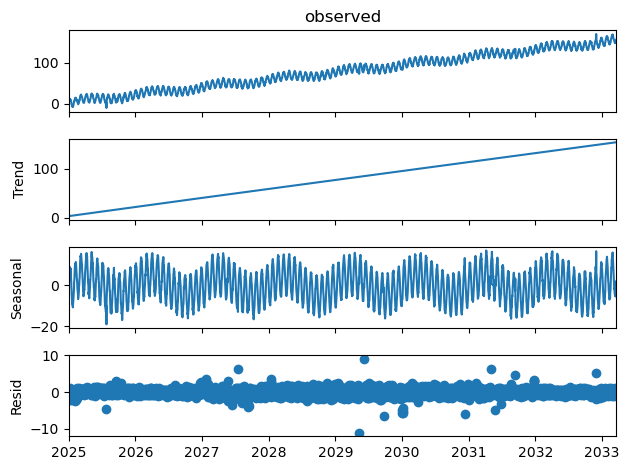

In [13]:
#period = 100
peaks = seasonal_peaks['period'][:2].apply(lambda x: x.days).values*24

res = MSTL(series,periods=peaks).fit()
res.plot()
plt.tight_layout()
plt.show()
# Plot the results
#plot_components(result_stl)

In [14]:
# ---------------------------------------------------------------------------
# Detect anomalies with Isolation Forest
# ---------------------------------------------------------------------------
anomalies, scores = detect_isolation_forest(
    series, contamination=0.015, lags=(1, 7, 14, 30), return_scores=True, random_state=0
)

# ---------------------------------------------------------------------------
# Plot the time series with detected anomalies highlighted
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
series.plot(ax=ax, label="Time series")
series[anomalies].plot(ax=ax, marker="o", ls="", label="Detected anomalies")
ax.set_title("Isolation Forest anomaly detection")
ax.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Display anomalies with their scores in an interactive table
# ---------------------------------------------------------------------------
df_anom = pd.DataFrame({"value": ts[anomalies], "score": scores[anomalies]})


NameError: name 'detect_isolation_forest' is not defined